# Imports and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import itertools

# %matplotlib widget
# plt.rc("text", usetex = False)
plt.rcParams["font.size"] = 16
# plt.rcParams["figure.facecolor"] = 'w'
# plt.style.use("classic")

fs = 20

def customCMAP(names = ["hot_r", "cool", "bone_r", "pink_r", "plasma_r"], ncolors: int = 256):

        for cmap in names:
            # if custom version of cmap already exists, skip it
            if cmap + 'T' in plt.colormaps():
                continue
            else:
            # create the colormap
                color_array = plt.get_cmap(cmap)(range(ncolors))
                color_array[:,-1] = np.power(np.linspace(0, 1.0, ncolors), 1/2) # adjusted so that the alpha increases quicker than linearly
                map_object = mcolors.LinearSegmentedColormap.from_list(name = cmap + 'T', colors = color_array)
                plt.colormaps.register(cmap = map_object)

customCMAP()

window_radius = 1e-2 # m

# Electron charge in C
e_charge = 1.602176634e-19

# ILC parameters
n_incident = 2.5e10 # number of electrons per bunch
n_bunches = 1312 # number of bunches per pulse
ILC_scale = n_bunches * n_incident # number of electrons in a bunch train

density = {
    "LXe": 2.953 * 1e6, # g/m^3
    "Be" : 1.848 * 1e6, # g/m^3
    "Al" : 2.699 * 1e6, # g/m^3
}

# n_electrons_per_pulse = n_incident / 20 # 20 beam pulses per bunch train WRONG ==> 1.25e9 e- per pulse
n_electrons_per_pulse = 66 * n_incident # 2.5e10 e- per bunch, 66 bunches in a pulse
pulse_time_sep = 3.3e-3 # 3.3 ms between pulses


In [2]:
materials = ["Be", "Al"]

def path(material: str, date: str = "jan2026", num: int = 4, ext: str = "out"):
    return f"/Users/max/SLAC Fall 2024/LXeSims/LXe_CFD_Target_Sims/datafilecell10v12{material}prof50us_{num}_{date}.{ext}"

data_cols = '"Time-Step" "flow-time" "delta-time" "dm-in-out" "flow-cellinds" "flow-cellinmidds" "flow-cellinmidus" "flow-cellinus" "flow-cellout" "iters-per-timestep" "p-inlet" "p-outlet" "power-inout" "rho-cell" "rhomin-cell" "tflow-cellout" "tflow-inlet" "tflow-outlet" "tmax-winin" "tmax-winout" "vflow-cell" "vflow-in" "vflow-outlet" "gasvolfrac-cell" "mdotlg-cell"'.replace('"', '').split(' ')

d_cols = "Absolute_time, vflow_R1, vflow_R2, density_R1, density_R2, Tave_R1, Tave_R2, Vol_R1, Vol_R2, number-of-cells_R1, number-of-cells_R2".replace(',','').split(' ')

In [3]:
data = pd.read_csv(path("Be", num=1), skiprows=3, delimiter=' ')
data.columns = '"Time-Step" "flow-time" "delta-time" "dm-in-out" "flow-cellinds" "flow-cellinmidds" "flow-cellinmidus" "flow-cellinus" "flow-cellout" "iters-per-timestep" "p-inlet" "p-outlet" "power-inout" "rho-cell" "rhomin-cell" "tflow-cellout" "tflow-inlet" "tflow-outlet" "tmax-winin" "tmax-winout" "vflow-cell" "vflow-in" "vflow-outlet" "gasvolfrac-cell" "mdotlg-cell"'.replace('"', '').split(' ')

# d contains data for cylindrical sub-volumes of the LXe
d = pd.read_csv(path("Be", num=1, ext="dat"), delimiter=' ')
d.columns = "Absolute_time, vflow_R1, vflow_R2, density_R1, density_R2, Tave_R1, Tave_R2, Vol_R1, Vol_R2, number-of-cells_R1, number-of-cells_R2".replace(',','').split(' ')



In [4]:
Be_data = []
Al_data = []

Be_offsets = []
Al_offsets = []

for i in range(1,5):
    Be_data.append(pd.read_csv(path("Be", num=i), skiprows=3, delimiter=' '))
    Be_data[i-1].columns = data_cols
    Be_offsets.append(len(Be_data[i-1]) - 1)

    if i > 1:
        Al_data.append(pd.read_csv(path("Al", date='dec2025', num=i), skiprows=3, delimiter=' '))
        Al_data[i-2].columns = data_cols
        Al_offsets.append(len(Be_data[i-2]) - 1)

Be = pd.concat(Be_data, ignore_index=True)
Al = pd.concat(Al_data, ignore_index=True)

Al_time_shifted = Al["Time-Step"] * Al["delta-time"] - Al["Time-Step"][0] * Al["delta-time"][0]
Be_time_shifted = Be["Time-Step"] * Be["delta-time"] - Be["Time-Step"][0] * Be["delta-time"][0]

Be_offsets = list(itertools.accumulate(Be_offsets))
Al_offsets = list(itertools.accumulate(Al_offsets))

In [5]:
Be_d = []
Al_d = []

Be_doff = []
Al_doff = []

for i in range(1,5):
    Be_d.append(pd.read_csv(path("Be", num=i, ext="dat"), skiprows=3, delimiter=' '))
    Be_d[i-1].columns = d_cols
    Be_doff.append(len(Be_d[i-1]) - 1)

    if i > 1:
        Al_d.append(pd.read_csv(path("Al", date='dec2025', num=i, ext="dat"), skiprows=3, delimiter=' '))
        Al_d[i-2].columns = d_cols
        Al_doff.append(len(Be_d[i-2]) - 1)

Be_df = pd.concat(Be_d, ignore_index=True)
Al_df = pd.concat(Al_d, ignore_index=True)

Be_doff = list(itertools.accumulate(Be_doff))
Al_doff = list(itertools.accumulate(Al_doff))

# Raw plots

In [23]:
print(Al_offsets[1], Be_offsets[1])

85611 85611


In [172]:
np.argmin(abs(Al_time_shifted - 2.9))

np.int64(58000)

In [148]:
# np.argmax(Be["tflow-cellout"][17280:17310])
# np.argmax(Al["tflow-cellout"][17450+so:17490+so])
17468+so - 17290

19178

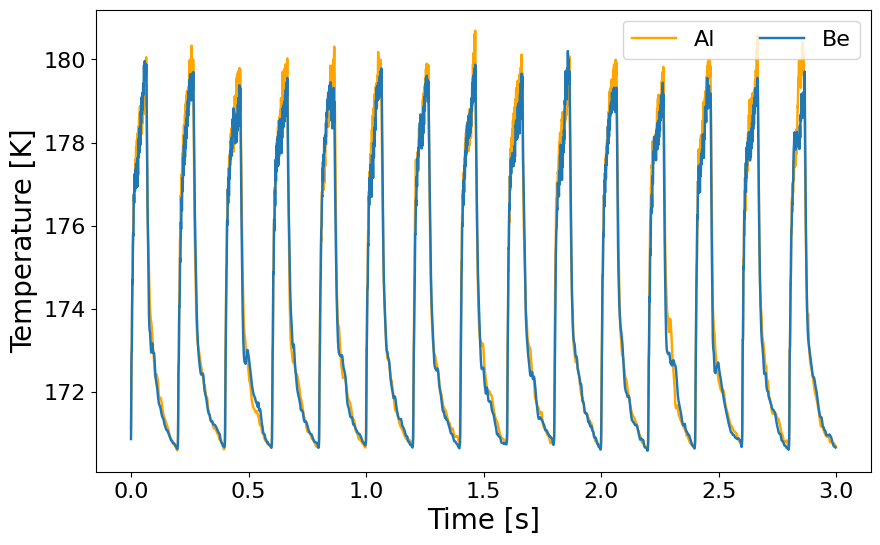

In [198]:
var = "tflow-cellout"

plt.close()
plt.figure(figsize=(10,6))

so = 19178 # 19000
end = 60000 - 60 # 85611

plt.plot(Al_time_shifted[:end], Al[var][so:end+so], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted[:end], Be[var][:end], c='tab:blue', label="Be", lw=1.75)

# plt.plot(Al_time_shifted[:Al_offsets[1]-so], Al[var][so:Al_offsets[1]], c='orange', label="Al", lw=1.75)
# plt.plot(Be_time_shifted[:Be_offsets[1]], Be[var][:Be_offsets[1]], c='tab:blue', label="Be", lw=1.75)

# plt.scatter(Al_time_shifted[end], Al[var][end+so], c='r', s=50)
# plt.scatter(Al_time_shifted[so], Al[var][so], c='r', s=50)

# for i in range(0, len(Al_offsets)):
#     plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')
#     plt.axvline(Be_time_shifted[Be_offsets[i]], 0, 1, c='k', ls='--')

# plt.axvline(Be_time_shifted[17450], 0, 1, c='k', ls='--')
# plt.axvline(Be_time_shifted[17490], 0, 1, c='k', ls='--')
# plt.scatter(Be_time_shifted[17468], Al[var][17468+so], c='r', s=50)

# plt.axvline(Be_time_shifted[17280], 0, 1, c='k', ls='--')
# plt.axvline(Be_time_shifted[17310], 0, 1, c='k', ls='--')
# plt.scatter(Be_time_shifted[17290], Be[var][17290], c='r', s=50)

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)

# n=3
# plt.xlim(-0.05+n,0.2+n)
# plt.xlim(0.84, 0.885)
# plt.xlim(1.05, 1.1)

plt.legend(ncols=2, loc="upper right")

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

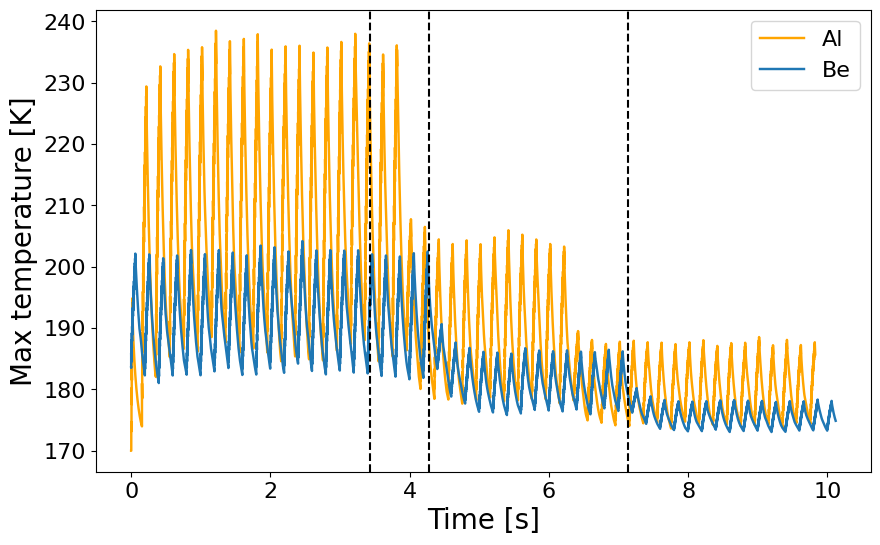

In [8]:
var = "tmax-winout"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Max temperature [K]", fontsize=fs)

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

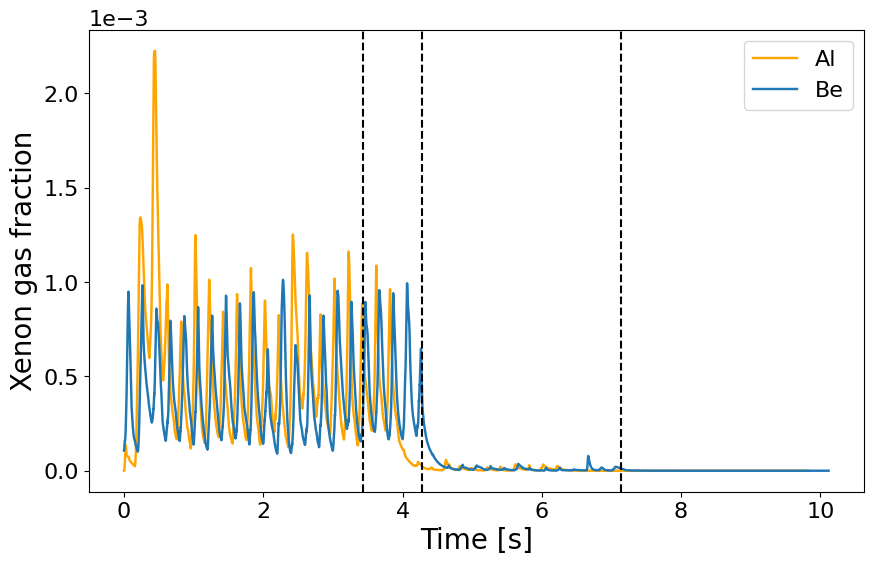

In [9]:
var = "gasvolfrac-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Xenon gas fraction", fontsize=fs)

plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# plt.rcParams['axes.formatter.use_mathtext'] = True

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

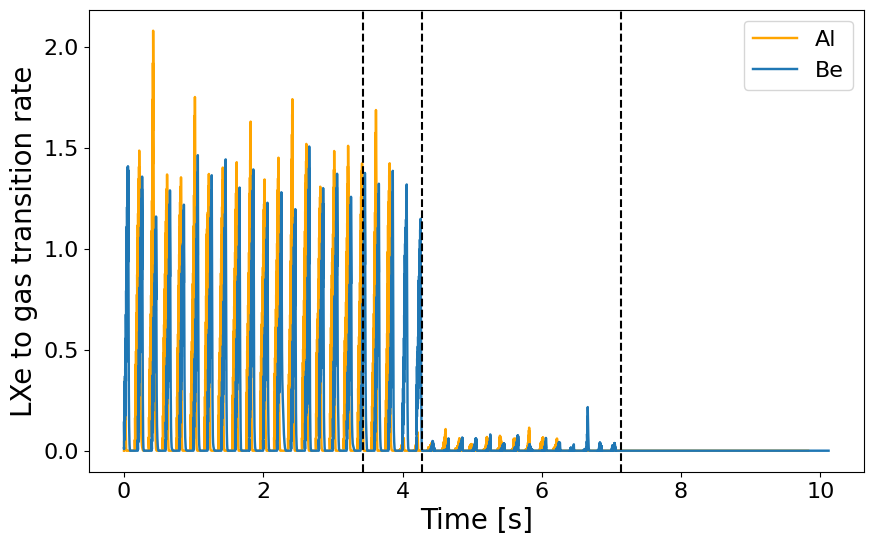

In [10]:
var = "mdotlg-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("LXe to gas transition rate", fontsize=fs)

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

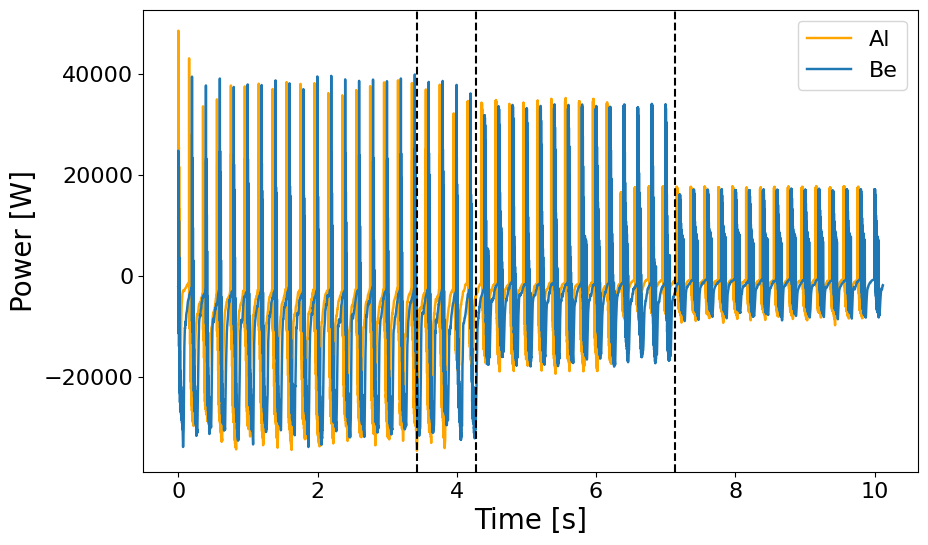

In [11]:
var = "power-inout"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='orange', label="Al", lw=1.75)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.75)

for i in range(0, len(Al_offsets)):
    plt.axvline(Al_time_shifted[Al_offsets[i]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Power [W]", fontsize=fs)

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}.pdf", dpi=500, bbox_inches="tight")

plt.show()

# Paper plots

In [ ]:
so = 19178
end = 60000 - 60

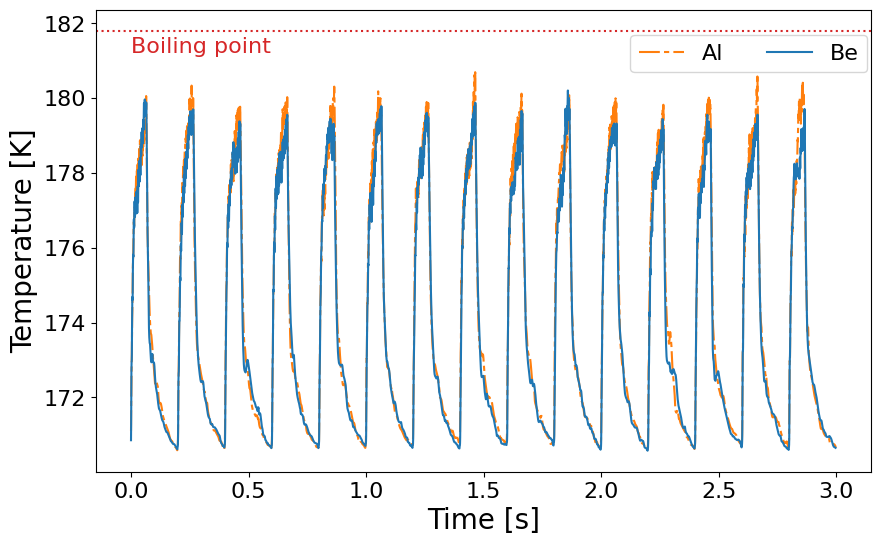

In [180]:
var = "tflow-cellout"

T_sat = 181.8

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted[:end], Al[var][so:end+so], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_time_shifted[:end], Be[var][:end], c='tab:blue', label="Be", lw=1.5)

plt.axhline(T_sat, 0, 1, ls=':', c='tab:red')
plt.text(0, T_sat-0.6, s="Boiling point", c='tab:red')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)
# plt.ylim(top=183)

plt.legend(loc="upper right"
            , ncols=2
            # , framealpha=0.5
            , bbox_to_anchor=(1.01, 0.97)
            # , bbox_to_anchor=(1, -0.015)
            )

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

In [272]:
var = "tmax-winout"
# np.argmin(Al[var][so+3900:3950+so])
np.argmin(Be[var][bo+3900:3950+bo])

np.int64(33)

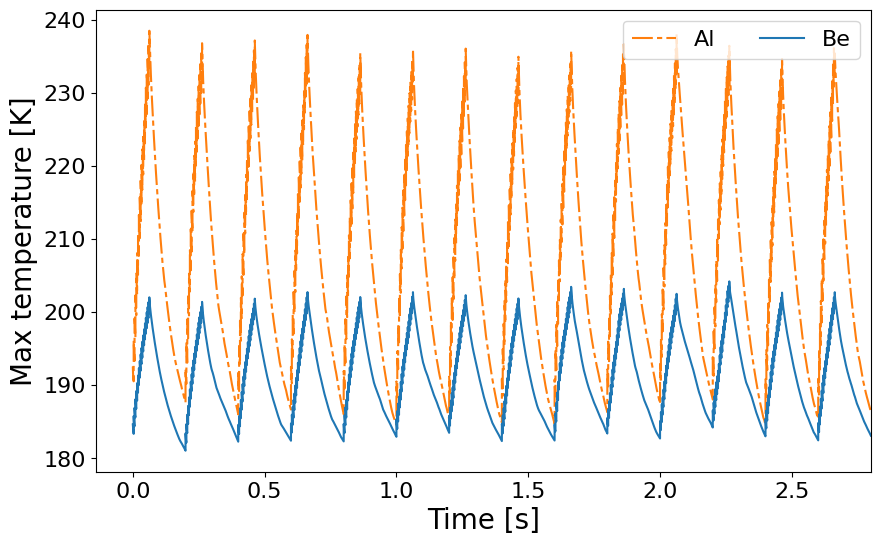

In [ ]:
var = "tmax-winout"

icut = 3934
bo = 13
so = 19178+5
end = 60000 - 60

plt.close()
plt.figure(figsize=(10,6))

# plt.scatter(Al_time_shifted[:end-icut], Al[var][icut+so:end+so], c='tab:orange', label="Al", s=5)
# plt.scatter(Be_time_shifted[:end-icut], Be[var][icut+bo:end+bo], c='tab:blue', label="Be", s=5)

plt.plot(Al_time_shifted[:end-icut], Al[var][icut+so:end+so], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_time_shifted[:end-icut], Be[var][icut+bo:end+bo], c='tab:blue', label="Be", lw=1.5)

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Max temperature [K]", fontsize=fs)
# plt.xlim(left=0.0, right=Al_time_shifted[Al_offsets[1]])

plt.legend(ncols=2, loc="upper right")
# fd = {"fontsize": 26, "weight": "bold"}
# plt.text(x=0.09, y=220, s="Al", fontdict=fd, color="tab:orange")
# plt.text(x=0.09, y=187, s="Be", fontdict=fd, color="tab:blue")

# plt.axvline(Be_time_shifted[3900], 0, 1, c='k', ls='--')
# plt.axvline(Be_time_shifted[3950], 0, 1, c='k', ls='--')

# plt.scatter(Al_time_shifted[3933], Al[var][3933+so], c='r', s=50)
# plt.scatter(Be_time_shifted[3933], Be[var][3933+bo], c='r', s=50)


# n=0 # 0.15
# plt.xlim(-0.05+n,0.2+n)
# plt.xlim(-0.01+n,0.02+n)
# plt.xlim(Be_time_shifted[3925]-0.01,Be_time_shifted[3925]+0.02)
plt.xlim(right=2.7998)

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_lined_up.pdf", dpi=500, bbox_inches="tight")

plt.show()

In [344]:
np.argmin(abs(Al_time_shifted[:end-icut] - 0.2))

np.int64(4000)

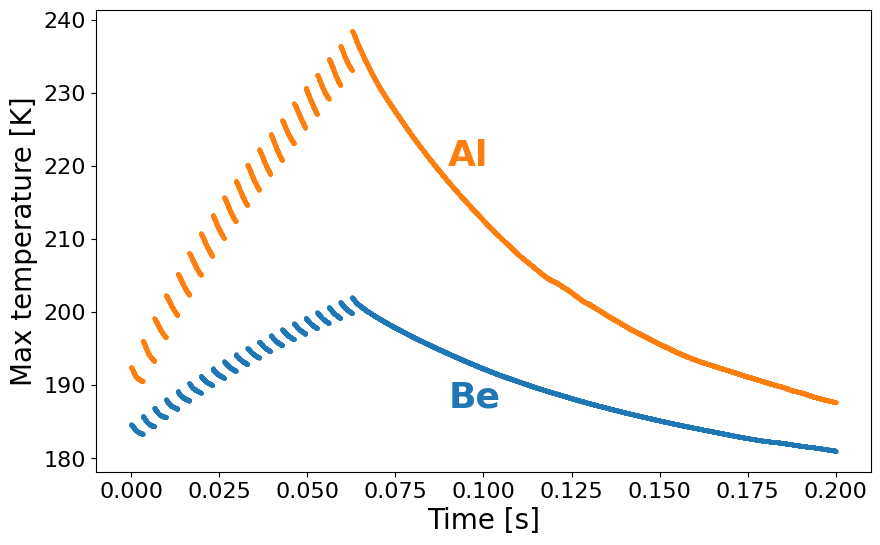

In [ ]:
var = "tmax-winout"

icut = 3934
bo = 13
so = 19178+5
end = 60000 - 60
io = 4000

plt.close()
plt.figure(figsize=(10,6))

plt.scatter(Al_time_shifted[:io], Al[var][icut+so:icut+io+so], c='tab:orange', label="Al", s=5)
plt.scatter(Be_time_shifted[:io], Be[var][icut+bo:icut+io+bo], c='tab:blue', label="Be", s=5)

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Max temperature [K]", fontsize=fs)
# plt.xlim(left=0.0, right=Al_time_shifted[Al_offsets[1]])

# plt.legend(ncols=2, loc="upper right")
fd = {"fontsize": 26, "weight": "bold"}
plt.text(x=0.09, y=220, s="Al", fontdict=fd, color="tab:orange")
plt.text(x=0.09, y=187, s="Be", fontdict=fd, color="tab:blue")

# plt.axvline(Be_time_shifted[3900], 0, 1, c='k', ls='--')
# plt.axvline(Be_time_shifted[3950], 0, 1, c='k', ls='--')

# plt.scatter(Al_time_shifted[3933], Al[var][3933+so], c='r', s=50)
# plt.scatter(Be_time_shifted[3933], Be[var][3933+bo], c='r', s=50)

idx = 1
# plt.scatter(Al_time_shifted[4000-idx], Al[var][icut+so+4000-idx], c='k', s=5)

n=0.2 # 0.15
# plt.xlim(-0.05+n,0.2+n)
# plt.xlim(-0.01+n,0.02+n)
# plt.xlim(Be_time_shifted[3925]-0.01,Be_time_shifted[3925]+0.02)

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

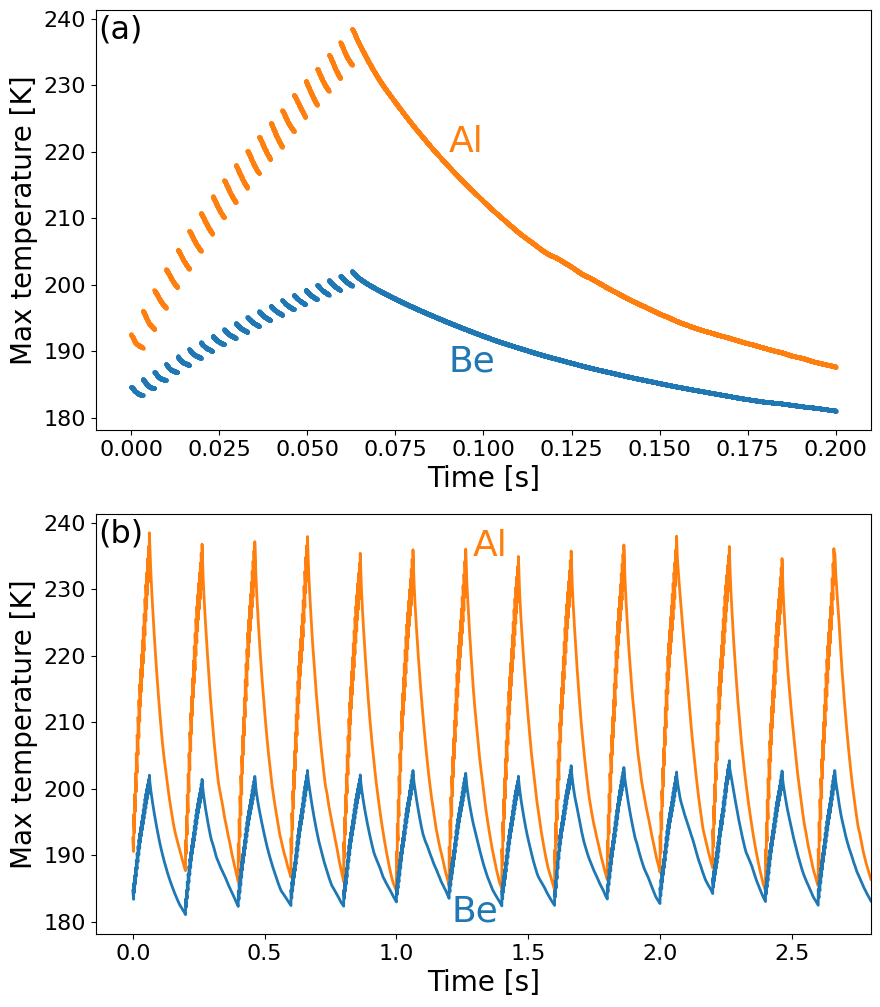

In [ ]:
var = "tmax-winout"

icut = 3934
bo = 13
so = 19178+5
end = 60000 - 60
io = 4000

fd = {"fontsize": 26, "fontweight": "normal"}
fdl = {"fontsize": 23, "fontweight": "normal"}

plt.close()
fig, ax = plt.subplots(2,1, figsize=(10,12))

single_train_plot_idx = 0

ax[~single_train_plot_idx].plot(Al_time_shifted[:end-icut], Al[var][icut+so:end+so], c='tab:orange', label="Al", lw=2.) #, ls=(0, (10, 2, 2.5, 2)))
ax[~single_train_plot_idx].plot(Be_time_shifted[:end-icut], Be[var][icut+bo:end+bo], c='tab:blue', label="Be", lw=2.)

ax[~single_train_plot_idx].set_xlabel("Time [s]", fontsize=fs)
ax[~single_train_plot_idx].set_ylabel("Max temperature [K]", fontsize=fs)

# ax[~single_train_plot_idx].legend(ncols=2, loc="upper right")
ax[~single_train_plot_idx].text(x=1.29, y=235, s="Al", fontdict=fd, color="tab:orange")
ax[~single_train_plot_idx].text(x=1.21, y=180, s="Be", fontdict=fd, color="tab:blue")

ax[~single_train_plot_idx].text(x=-0.13, y=237, s="(b)", fontdict=fdl, color="k")


# ax[~single_train_plot_idx].axvline(Be_time_shifted[24000], 0, 1, c='k', ls='--')
ax[~single_train_plot_idx].set_xlim(right=2.7998)


ax[single_train_plot_idx].scatter(Al_time_shifted[:io], Al[var][icut+so:icut+io+so], c='tab:orange', label="Al", s=5)
ax[single_train_plot_idx].scatter(Be_time_shifted[:io], Be[var][icut+bo:icut+io+bo], c='tab:blue', label="Be", s=5)

ax[single_train_plot_idx].set_xlabel("Time [s]", fontsize=fs)
ax[single_train_plot_idx].set_ylabel("Max temperature [K]", fontsize=fs)

ax[single_train_plot_idx].text(x=0.09, y=220, s="Al", fontdict=fd, color="tab:orange")
ax[single_train_plot_idx].text(x=0.09, y=187, s="Be", fontdict=fd, color="tab:blue")

ax[single_train_plot_idx].text(x=-0.0094, y=237, s="(a)", fontdict=fdl, color="k")

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_subplots.pdf", dpi=500, bbox_inches="tight")

plt.show()

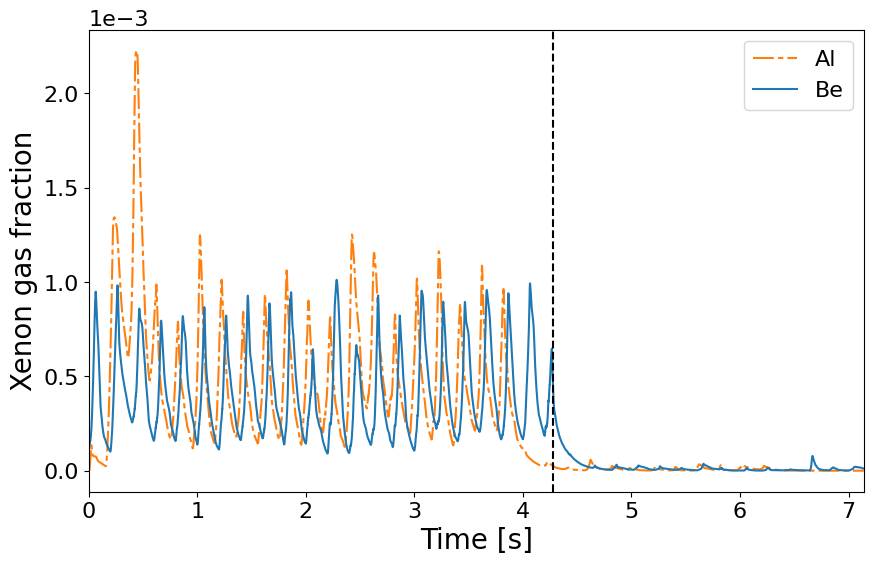

In [14]:
var = "gasvolfrac-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.5)
plt.axvline(Al_time_shifted[Al_offsets[1]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Xenon gas fraction", fontsize=fs)


plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# plt.rcParams['axes.formatter.use_mathtext'] = True
plt.xlim(left=0.0, right=Al_time_shifted[Al_offsets[2]])




plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

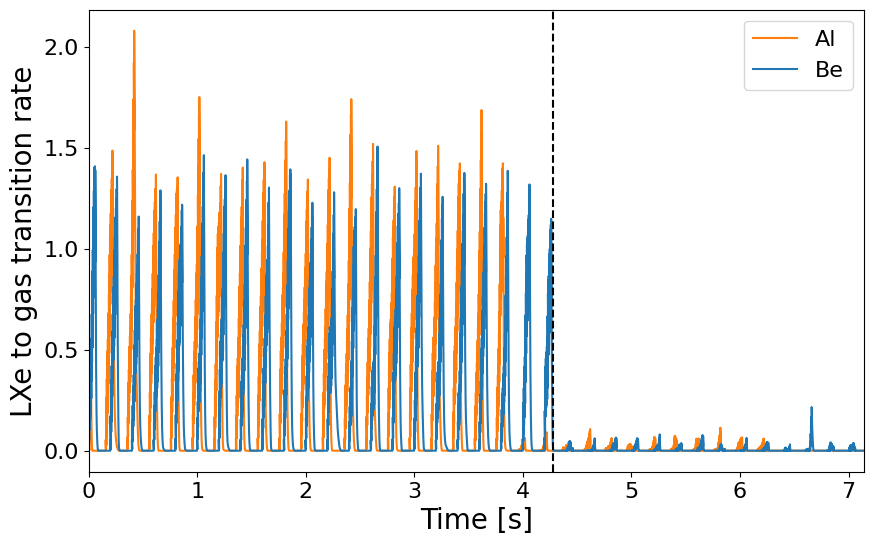

In [15]:
var = "mdotlg-cell"

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_time_shifted, Al[var], c='tab:orange', label="Al", lw=1.5)
plt.plot(Be_time_shifted, Be[var], c='tab:blue', label="Be", lw=1.5)

plt.axvline(Al_time_shifted[Al_offsets[1]], 0, 1, c='k', ls='--')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("LXe to gas transition rate", fontsize=fs)
plt.xlim(left=0, right=Al_time_shifted[Al_offsets[2]])

plt.legend()

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

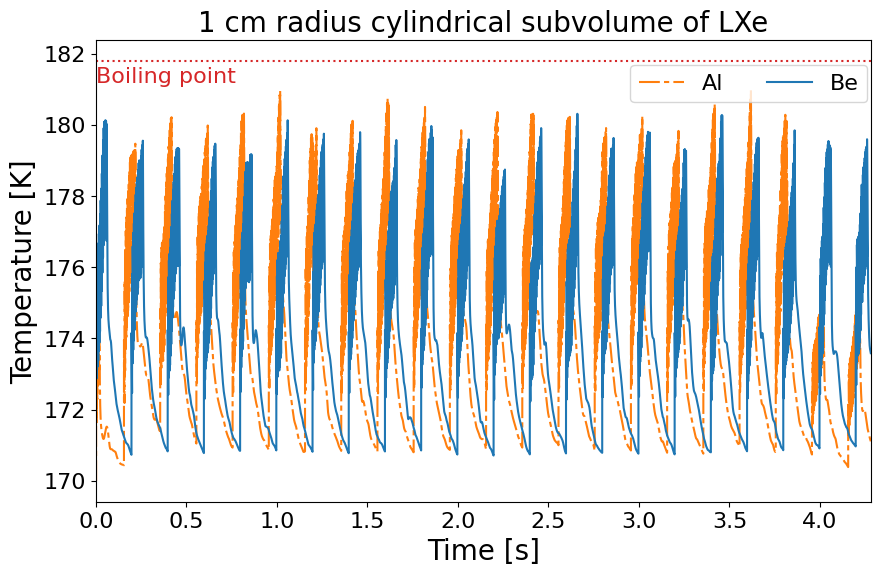

In [16]:
var = "Tave_R1"

T_sat = 181.8

Al_d_time_shifted = Al_df["Absolute_time"] - Al_df["Absolute_time"][0]

plt.close()
plt.figure(figsize=(10,6))

plt.plot(Al_d_time_shifted, Al_df[var], c='tab:orange', label="Al", lw=1.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_df["Absolute_time"] - Be_df["Absolute_time"][0], Be_df[var], c='tab:blue', label="Be", lw=1.5)

plt.axhline(T_sat, 0, 1, ls=':', c='tab:red')
plt.text(0, T_sat-0.6, s="Boiling point", c='tab:red')

plt.xlim(left=0, right=Al_d_time_shifted[Al_doff[1]])

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)
plt.title("1 cm radius cylindrical subvolume of LXe", fontsize=fs)

plt.legend(loc="upper right"
            , ncols=2
            # , framealpha=0.5
            , bbox_to_anchor=(1.01, 0.97)
            # , bbox_to_anchor=(1, -0.015)
            )

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

# Lined up data

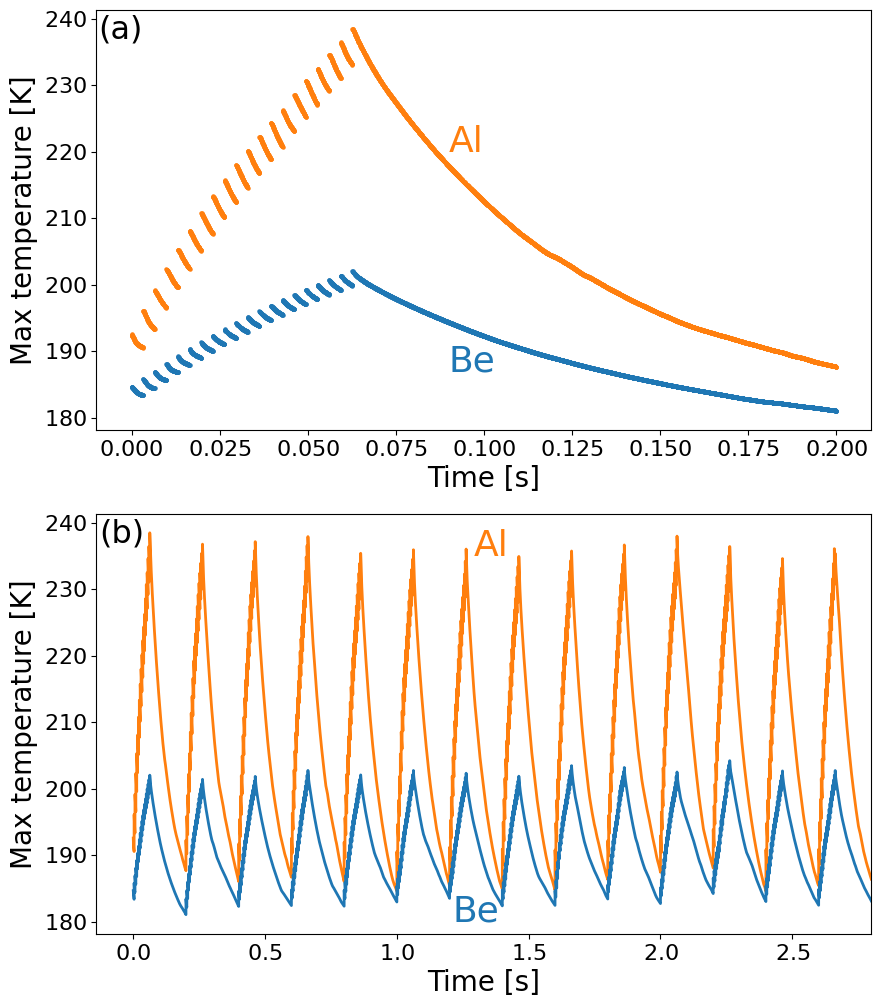

In [ ]:
var = "tmax-winout"

icut = 3934
bo = 13
so = 19178+5
end = 60000 - 60
io = 4000

fd = {"fontsize": 26, "fontweight": "normal"}
fdl = {"fontsize": 23, "fontweight": "normal"}

plt.close()
fig, ax = plt.subplots(2,1, figsize=(10,12))

single_train_plot_idx = 0

ax[~single_train_plot_idx].plot(Al_time_shifted[:end-icut], Al[var][icut+so:end+so], c='tab:orange', label="Al", lw=2.) #, ls=(0, (10, 2, 2.5, 2)))
ax[~single_train_plot_idx].plot(Be_time_shifted[:end-icut], Be[var][icut+bo:end+bo], c='tab:blue', label="Be", lw=2.)

ax[~single_train_plot_idx].set_xlabel("Time [s]", fontsize=fs)
ax[~single_train_plot_idx].set_ylabel("Max temperature [K]", fontsize=fs)

# ax[~single_train_plot_idx].legend(ncols=2, loc="upper right")
ax[~single_train_plot_idx].text(x=1.29, y=235, s="Al", fontdict=fd, color="tab:orange")
ax[~single_train_plot_idx].text(x=1.21, y=180, s="Be", fontdict=fd, color="tab:blue")

ax[~single_train_plot_idx].text(x=-0.13, y=237, s="(b)", fontdict=fdl, color="k")


# ax[~single_train_plot_idx].axvline(Be_time_shifted[24000], 0, 1, c='k', ls='--')
ax[~single_train_plot_idx].set_xlim(right=2.7998)


ax[single_train_plot_idx].scatter(Al_time_shifted[:io], Al[var][icut+so:icut+io+so], c='tab:orange', label="Al", s=5)
ax[single_train_plot_idx].scatter(Be_time_shifted[:io], Be[var][icut+bo:icut+io+bo], c='tab:blue', label="Be", s=5)

ax[single_train_plot_idx].set_xlabel("Time [s]", fontsize=fs)
ax[single_train_plot_idx].set_ylabel("Max temperature [K]", fontsize=fs)

ax[single_train_plot_idx].text(x=0.09, y=220, s="Al", fontdict=fd, color="tab:orange")
ax[single_train_plot_idx].text(x=0.09, y=187, s="Be", fontdict=fd, color="tab:blue")

ax[single_train_plot_idx].text(x=-0.0094, y=237, s="(a)", fontdict=fdl, color="k")

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_subplots.pdf", dpi=500, bbox_inches="tight")

plt.show()

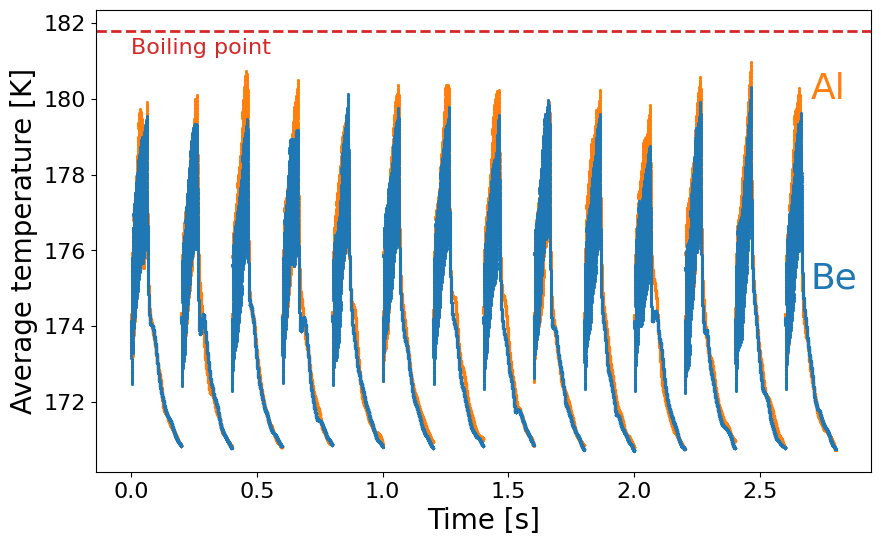

In [565]:
var = "Tave_R1"

icut = 3934
bo = 13
so = 19178+5
end = 60000 - 60 - 13
io = 4000

T_sat = 181.8

Al_d_time_shifted = Al_df["Absolute_time"] - Al_df["Absolute_time"][0]
Be_d_time_shifted = Be_df["Absolute_time"] - Be_df["Absolute_time"][0]

plt.close()
plt.figure(figsize=(10,6))

# plt.plot(Al_d_time_shifted[:end-icut], Al_df[var][icut+so:end+so], c='tab:orange', label="Al", lw=2.5)
# plt.plot(Be_d_time_shifted[:end-icut], Be_df[var][icut+bo:end+bo], c='tab:blue', label="Be", lw=2.0)
plt.scatter(Al_d_time_shifted[:end-icut], Al_df[var][icut+so:end+so], c='tab:orange', label="Al", s=1.5)
plt.scatter(Be_d_time_shifted[:end-icut], Be_df[var][icut+bo:end+bo], c='tab:blue', label="Be", s=1.5)

plt.axhline(T_sat, 0, 1, ls='--', c='tab:red', lw=2)
plt.text(0, T_sat-0.6, s="Boiling point", c='tab:red')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Average temperature [K]", fontsize=fs)
# plt.title("1 cm radius cylindrical subvolume of LXe", fontsize=fs)

fd = {"fontsize": 26, "weight": "normal"}
plt.text(x=2.7, y=180, s="Al", fontdict=fd, color="tab:orange")
plt.text(x=2.7, y=175, s="Be", fontdict=fd, color="tab:blue")

# plt.legend(loc="upper right"
#             , ncols=2
#             # , framealpha=0.5
#             , bbox_to_anchor=(1.01, 0.97)
#             # , bbox_to_anchor=(1, -0.015)
#             )

# plt.xlim(2.799, 2.81)
# n=0.2
# plt.xlim(-0.05+n,0.2+n)
# plt.xlim(-0.01+n,0.02+n)

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_lined_up.png", dpi=500, bbox_inches="tight")

plt.show()

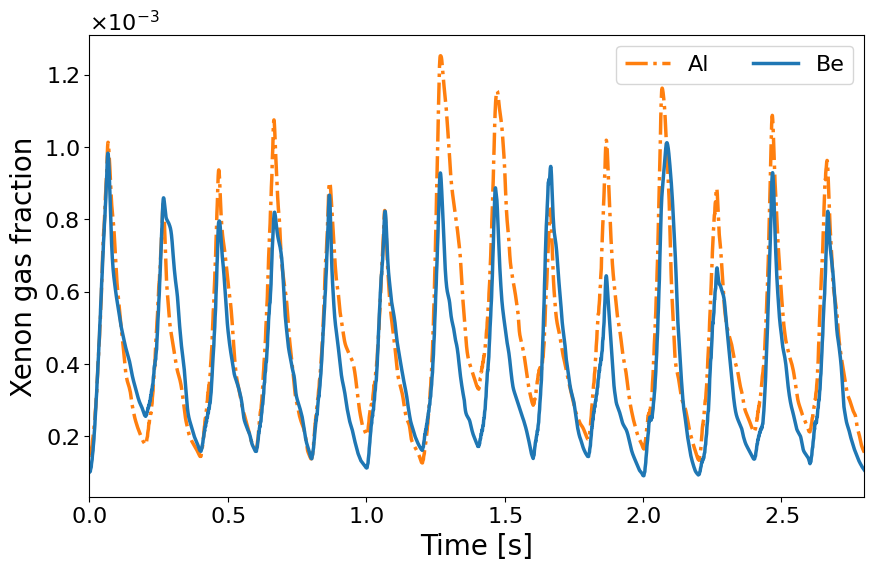

In [584]:
var = "gasvolfrac-cell"

icut = 3934
bo = 13
so = 19178+5
end = 60000 - 60

plt.close()
plt.figure(figsize=(10,6))

# plt.scatter(Al_time_shifted[:end-icut], Al[var][icut+so:end+so], c='tab:orange', label="Al", s=5)
# plt.scatter(Be_time_shifted[:end-icut], Be[var][icut+bo:end+bo], c='tab:blue', label="Be", s=5)

plt.plot(Al_time_shifted[:end-icut], Al[var][icut+so:end+so], c='tab:orange', label="Al", lw=2.5, ls="-.")
plt.plot(Be_time_shifted[:end-icut], Be[var][icut+bo:end+bo], c='tab:blue', label="Be", lw=2.5)

# plt.xlim(left=0.0, right=Al_time_shifted[Al_offsets[1]])

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Xenon gas fraction", fontsize=fs)


plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
# plt.rcParams['axes.formatter.use_mathtext'] = True

plt.legend(ncols=2, loc="upper right")
# fd = {"fontsize": 26, "weight": "bold"}
# plt.text(x=0.09, y=220, s="Al", fontdict=fd, color="tab:orange")
# plt.text(x=0.09, y=187, s="Be", fontdict=fd, color="tab:blue")

# plt.axvline(Be_time_shifted[3900], 0, 1, c='k', ls='--')
# plt.axvline(Be_time_shifted[3950], 0, 1, c='k', ls='--')

# plt.scatter(Al_time_shifted[3933], Al[var][3933+so], c='r', s=50)
# plt.scatter(Be_time_shifted[3933], Be[var][3933+bo], c='r', s=50)


# n=0 # 0.15
# plt.xlim(-0.05+n,0.2+n)
# plt.xlim(-0.01+n,0.02+n)
# plt.xlim(Be_time_shifted[3925]-0.01,Be_time_shifted[3925]+0.02)
plt.xlim(left=0,right=2.7998)

plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_lined_up.pdf", dpi=500, bbox_inches="tight")

plt.show()

# Old lined up data

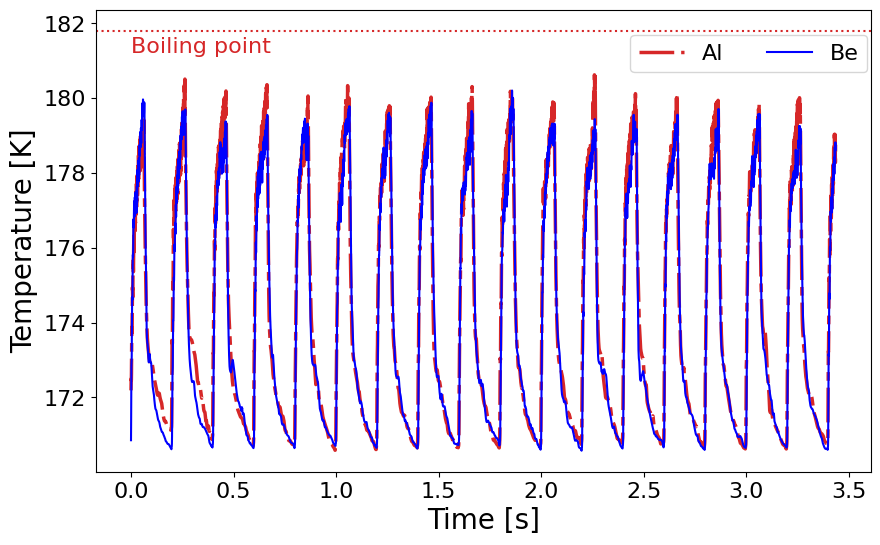

In [8]:
var = "tflow-cellout"

T_sat = 181.8

plt.close()
plt.figure(figsize=(10,6))

k=3200
plt.plot(Al_time_shifted[:Al_offsets[0]], Al[var][k:Al_offsets[0]+k], c='tab:red', label="Al", lw=2.5, ls=(0, (10, 2, 2.5, 2)))
plt.plot(Be_time_shifted[:Be_offsets[0]], Be[var][:Be_offsets[0]], c='blue', label="Be", lw=1.5)

plt.axhline(T_sat, 0, 1, ls=':', c='tab:red')
plt.text(0, T_sat-0.6, s="Boiling point", c='tab:red')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)
# plt.ylim(top=183)

plt.legend(loc="upper right"
            , ncols=2
            # , framealpha=0.5
            , bbox_to_anchor=(1.01, 0.97)
            # , bbox_to_anchor=(1, -0.015)
            )

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_lined_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

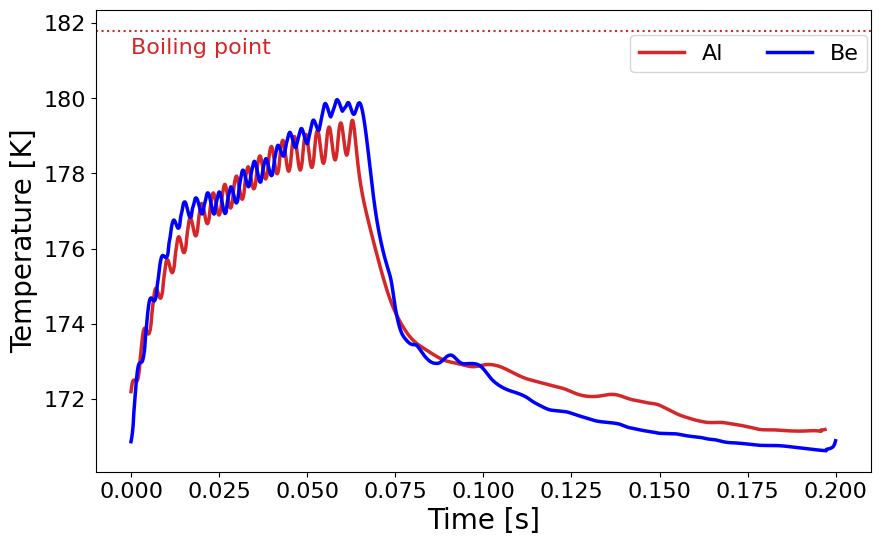

In [71]:
var = "tflow-cellout"

T_sat = 181.8

plt.close()
plt.figure(figsize=(10,6))

end = np.argmin(abs(Al_time_shifted - 0.2)) - 60
Bend = np.argmin(abs(Be_time_shifted - 0.2)) - 0
k = 3200

plt.plot(Al_time_shifted[:end], Al[var][k:end+k], c='tab:red', label="Al", lw=2.5)
plt.plot(Be_time_shifted[:Bend], Be[var][:Bend], c='blue', label="Be", lw=2.5)

plt.axhline(T_sat, 0, 1, ls=':', c='tab:red')
plt.text(0, T_sat-0.6, s="Boiling point", c='tab:red')

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Temperature [K]", fontsize=fs)
# plt.ylim(top=183)

plt.legend(loc="upper right"
            , ncols=2
            # , framealpha=0.5
            , bbox_to_anchor=(1.01, 0.97)
            # , bbox_to_anchor=(1, -0.015)
            )

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_lined_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()

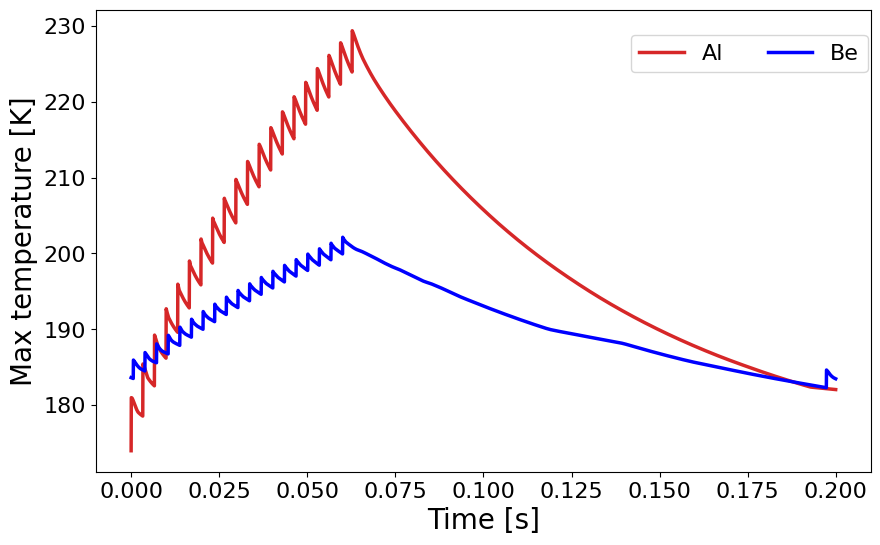

In [26]:
var = "tmax-winout"

plt.close()
plt.figure(figsize=(10,6))

end = np.argmin(abs(Al_time_shifted - 0.2)) - 0
Bend = np.argmin(abs(Be_time_shifted - 0.2)) - 0
k = 3116

plt.plot(Al_time_shifted[:end], Al[var][k:end+k], c='tab:red', label="Al", lw=2.5)
plt.plot(Be_time_shifted[:Bend], Be[var][:Bend], c='blue', label="Be", lw=2.5)

plt.xlabel("Time [s]", fontsize=fs)
plt.ylabel("Max temperature [K]", fontsize=fs)
# plt.ylim(top=183)

plt.legend(loc="upper right"
            , ncols=2
            # , framealpha=0.5
            , bbox_to_anchor=(1.01, 0.97)
            # , bbox_to_anchor=(1, -0.015)
            )

# plt.savefig(f"/Users/max/SLAC Fall 2024/LXeSims/Figures/{var}_lined_trimmed.pdf", dpi=500, bbox_inches="tight")

plt.show()